# Entrega Inicial: "Impacto en viajes del transporte público de Santiago"

### **Contexto**
El sistema de transporte público Red Metropolitana de Movilidad en Santiago es una red dinámica que debe adaptar su oferta para satisfacer las variaciones extremas de la demanda a lo largo de la semana. Nuestro proyecto se enfocará en analizar críticamente cómo esta adaptación de la oferta se plasma en los datos de la GTFS (General Transit Feed Specification) vigente y cómo impacta en diferentes áreas geográficas de la ciudad.

El desafío de la planificación no solo radica en cubrir la demanda máxima de los días laborales (peak), sino también en asignar recursos de manera eficiente durante los fines de semana, cuando los patrones de viaje cambian drásticamente (viajes recreativos, menor densidad de pasajeros, horarios de servicio más restringidos).

### **Motivación**
Como estudiantes de ciencia de datos, nos motiva aplicar técnicas de Análisis de Datos para evaluar la equidad y eficiencia del sistema de transporte en función del tiempo y el espacio. Específicamente, buscamos:

**1.- Cuantificar la Disparidad Semanal:** Mapear y cuantificar las diferencias en la oferta de transporte programada (frecuencias, cobertura de paradas) entre un día laboral y un fin de semana. Esto es crucial, ya que la diferencia en la calidad del servicio entre semana y fin de semana afecta la movilidad de los trabajadores con horarios no tradicionales y el acceso a servicios básicos.

**2.- Identificar la Vulnerabilidad Geográfica:** Analizar si las comunas periféricas o sectores específicos, que dependen fuertemente del bus, experimentan una reducción de servicio proporcionalmente mayor durante el fin de semana en comparación con las zonas centrales. Este análisis espacial tiene implicancias directas en la planificación urbana.

**3.- Generar decisiones operacionales:** Nuestro objetivo es generar visualizaciones y métricas concisas que puedan ser utilizadas por la DTPM o futuros estudios para optimizar la programación de itinerarios (frecuencias y distribución de flota) en función de la localización y el día, buscando la estabilidad y predictibilidad del servicio.


In [1]:
import datetime

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# reduced_files = [
#     "../data/reduced/2025-04-21.csv",
#     "../data/reduced/2025-04-22.csv",
#     "../data/reduced/2025-04-23.csv",
#     "../data/reduced/2025-04-27.csv",
#     "../data/reduced/2025-04-24.csv",
#     "../data/reduced/2025-04-25.csv",
#     "../data/reduced/2025-04-26.csv"
# ]

# sample_files = [
#     "../data/sample/2025-04-21_sample.csv",
#     "../data/sample/2025-04-22_sample.csv",
#     "../data/sample/2025-04-23_sample.csv",
#     "../data/sample/2025-04-27_sample.csv",
#     "../data/sample/2025-04-24_sample.csv",
#     "../data/sample/2025-04-25_sample.csv",
#     "../data/sample/2025-04-26_sample.csv"
# ]

# dfs = []
# for file in files:
#     df = pd.read_csv(file)
#     dfs.append(df)

In [3]:
# df = dfs[0]
df = pd.read_csv("../data/reduced/2025-04-21.csv")
df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada
0,BUS,1,2025-04-21 08:48:04,2025-04-21 08:50:39,155,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853,825,347180,6301636,347201,6302489
1,BUS,1,2025-04-21 08:51:46,2025-04-21 08:54:58,192,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090,983,347200,6302473,346625,6303299
2,BUS,1,2025-04-21 15:34:28,2025-04-21 15:39:01,273,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127,959,346563,6303315,347168,6302522
3,METRO,0,2025-04-21 17:27:55,-,-,LAS CONDES,-,LOS DOMINICOS,-,-,-,356329,6302427,-,-
4,METRO,1,2025-04-21 09:12:16,2025-04-21 09:38:40,1584,ESTACION CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240,3064,343933,6297455,346372,6299031


# Limpieza

In [4]:
df.replace("-", np.nan, inplace=True)

# limpieza con comunas con tilde
comunas_con_tilde = {
    "SAN JOAQUIN": "SAN JOAQUÍN",
    "SAN RAMON": "SAN RAMÓN",
    "PENALOLEN": "PEÑALOLÉN",
    "NUNOA": "ÑUÑOA",
    "MAIPU": "MAIPÚ",
    "CONCHALI": "CONCHALÍ",
    "ESTACION CENTRAL": "ESTACIÓN CENTRAL"
}
def comunas_map(comuna):
    if comuna in comunas_con_tilde:
        return comunas_con_tilde[comuna]
    return comuna
df["comuna_subida"] = df["comuna_subida"].map(comunas_map)
df["comuna_bajada"] = df["comuna_bajada"].map(comunas_map)

In [5]:
transfo_df = df.copy()
transfo_df["tiempo_subida"] = pd.to_datetime(transfo_df["tiempo_subida"])
transfo_df["tiempo_bajada"] = pd.to_datetime(transfo_df["tiempo_bajada"])

transfo_df["tipo_transporte"] = transfo_df["tipo_transporte"].astype("category")
transfo_df["comuna_subida"] = transfo_df["comuna_subida"].astype("category")
transfo_df["comuna_bajada"] = transfo_df["comuna_bajada"].astype("category")
transfo_df["parada_bajada"] = transfo_df["parada_bajada"].astype("category")
transfo_df["parada_subida"] = transfo_df["parada_subida"].astype("category")

transfo_df["tiempo_etapa"] = transfo_df["tiempo_etapa"].astype(float)
transfo_df["x_bajada"] = transfo_df["x_bajada"].astype(float)
transfo_df["y_bajada"] = transfo_df["y_bajada"].astype(float)
transfo_df["x_subida"] = transfo_df["x_bajada"].astype(float)
transfo_df["y_subida"] = transfo_df["y_bajada"].astype(float)
transfo_df["dist_eucl_paraderos"] = transfo_df["dist_eucl_paraderos"].astype(float)
transfo_df["dist_ruta_paraderos"] = transfo_df["dist_ruta_paraderos"].astype(float)

transfo_df["tiene_bajada"] = transfo_df["tiene_bajada"].astype(bool)

transfo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4855306 entries, 0 to 4855305
Data columns (total 15 columns):
 #   Column               Dtype         
---  ------               -----         
 0   tipo_transporte      category      
 1   tiene_bajada         bool          
 2   tiempo_subida        datetime64[ns]
 3   tiempo_bajada        datetime64[ns]
 4   tiempo_etapa         float64       
 5   comuna_subida        category      
 6   comuna_bajada        category      
 7   parada_subida        category      
 8   parada_bajada        category      
 9   dist_ruta_paraderos  float64       
 10  dist_eucl_paraderos  float64       
 11  x_subida             float64       
 12  y_subida             float64       
 13  x_bajada             float64       
 14  y_bajada             float64       
dtypes: bool(1), category(5), datetime64[ns](2), float64(7)
memory usage: 371.1 MB


# EDA

In [6]:
transfo_df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada
0,BUS,True,2025-04-21 08:48:04,2025-04-21 08:50:39,155.0,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853.0,825.0,347201.0,6302489.0,347201.0,6302489.0
1,BUS,True,2025-04-21 08:51:46,2025-04-21 08:54:58,192.0,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090.0,983.0,346625.0,6303299.0,346625.0,6303299.0
2,BUS,True,2025-04-21 15:34:28,2025-04-21 15:39:01,273.0,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127.0,959.0,347168.0,6302522.0,347168.0,6302522.0
3,METRO,False,2025-04-21 17:27:55,NaT,NaN,LAS CONDES,NaN,LOS DOMINICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,METRO,True,2025-04-21 09:12:16,2025-04-21 09:38:40,1584.0,ESTACIÓN CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240.0,3064.0,346372.0,6299031.0,346372.0,6299031.0


In [7]:
def map_time_range(date):
    time = date.time()
    if (datetime.time(00, 00, 00) <= time) and (time <= datetime.time(5, 59, 59)):
        return "early"
    elif (datetime.time(6, 00, 00) <= time) and (time <= datetime.time(11, 59, 59)):
        return "morning"
    elif (datetime.time(12, 00, 00) <= time) and (time <= datetime.time(17, 59, 59)):
        return "afternoon"
    elif (datetime.time(18, 00, 00) <= time) and (time <= datetime.time(23, 59, 59)):
        return "night"

transfo_df["time_range"] = transfo_df["tiempo_subida"].map(map_time_range)

In [8]:
def map_time_type(date):
    time = date.time()
    if (datetime.time(6, 00, 00) <= time) and (time <= datetime.time(8, 59, 59)):
        return "rush_time-morning"
    elif (datetime.time(17, 00, 00) <= time) and (time <= datetime.time(19, 59, 59)):
        return "rush_time-night"
    else:
        return "normal"

transfo_df["time_type"] = transfo_df["tiempo_subida"].map(map_time_type)
transfo_df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada,time_range,time_type
0,BUS,True,2025-04-21 08:48:04,2025-04-21 08:50:39,155.0,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853.0,825.0,347201.0,6302489.0,347201.0,6302489.0,morning,rush_time-morning
1,BUS,True,2025-04-21 08:51:46,2025-04-21 08:54:58,192.0,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090.0,983.0,346625.0,6303299.0,346625.0,6303299.0,morning,rush_time-morning
2,BUS,True,2025-04-21 15:34:28,2025-04-21 15:39:01,273.0,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127.0,959.0,347168.0,6302522.0,347168.0,6302522.0,afternoon,normal
3,METRO,False,2025-04-21 17:27:55,NaT,NaN,LAS CONDES,NaN,LOS DOMINICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,afternoon,rush_time-night
4,METRO,True,2025-04-21 09:12:16,2025-04-21 09:38:40,1584.0,ESTACIÓN CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240.0,3064.0,346372.0,6299031.0,346372.0,6299031.0,morning,normal


### ¿Cómo varía el tiempo de viaje respecto la hora (hora normal y hora de punta)?

hora de punta: 6-9am 5-8pm

In [9]:
df_has_bajada = transfo_df[transfo_df["tiene_bajada"] == True]
df_has_bajada.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada,time_range,time_type
0,BUS,True,2025-04-21 08:48:04,2025-04-21 08:50:39,155.0,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853.0,825.0,347201.0,6302489.0,347201.0,6302489.0,morning,rush_time-morning
1,BUS,True,2025-04-21 08:51:46,2025-04-21 08:54:58,192.0,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090.0,983.0,346625.0,6303299.0,346625.0,6303299.0,morning,rush_time-morning
2,BUS,True,2025-04-21 15:34:28,2025-04-21 15:39:01,273.0,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127.0,959.0,347168.0,6302522.0,347168.0,6302522.0,afternoon,normal
4,METRO,True,2025-04-21 09:12:16,2025-04-21 09:38:40,1584.0,ESTACIÓN CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240.0,3064.0,346372.0,6299031.0,346372.0,6299031.0,morning,normal
5,METRO,True,2025-04-21 10:49:35,2025-04-21 11:17:20,1665.0,SANTIAGO,LA FLORIDA,PLAZA DE ARMAS,BELLAVISTA DE LA FLORIDA,11630.0,10307.0,351430.0,6289929.0,351430.0,6289929.0,morning,normal


In [10]:
df_has_bajada.groupby("time_type").agg({"tiempo_etapa": "mean"})

,tiempo_etapa
time_type,
normal,1170.222742
rush_time-morning,1336.311544
rush_time-night,1348.333420


In [11]:
df_has_bajada.groupby(["time_type", "tipo_transporte"], observed=True).agg({"tiempo_etapa": "mean"})

tiempo_etapa
time_type         tipo_transporte              
normal            BUS                910.083856
                  METRO             1404.931747
                  METROTREN          818.163365
                  ZP                1073.179436
rush_time-morning BUS               1028.553282
                  METRO             1594.244718
                  METROTREN          873.048247
                  ZP                1214.623057
rush_time-night   BUS               1135.530931
                  METRO             1516.261965
                  METROTREN          838.640985
                  ZP                1223.993743

### ¿Cómo varían la comuna subida y comuna bajada respecto la hora?
(cómo circulan las gentes.)

hora: 
early [0-6)
morning [6-12)
afternoon [12-18)
night [18-24)


In [12]:
pv_subida = pd.pivot_table(data=df_has_bajada, index='comuna_subida', columns="time_range", aggfunc="size", observed=False)
pv_bajada = pd.pivot_table(data=df_has_bajada, index='comuna_bajada', columns="time_range", aggfunc="size", observed=False)

In [13]:
pv_subida.sort_values(by="early", ascending=False).head()[["early"]]

time_range,early
comuna_subida,
PUENTE ALTO,6214
MAIPÚ,4391
LA FLORIDA,3009
SANTIAGO,2353
PUDAHUEL,1834


In [14]:
pv_bajada.sort_values(by="early", ascending=False).head()[["early"]]

time_range,early
comuna_bajada,
SANTIAGO,6020
LAS CONDES,3695
PUENTE ALTO,3132
PROVIDENCIA,2988
MAIPÚ,2754


In [15]:
pv_subida.sort_values(by="morning", ascending=False).head()[["morning"]]

time_range,morning
comuna_subida,
SANTIAGO,175416
PUENTE ALTO,113067
MAIPÚ,106773
LAS CONDES,98578
ÑUÑOA,88543


In [16]:
pv_bajada.sort_values(by="morning", ascending=False).head()[["morning"]]

time_range,morning
comuna_bajada,
SANTIAGO,299191
PROVIDENCIA,203518
LAS CONDES,176730
ÑUÑOA,86232
ESTACIÓN CENTRAL,75050


In [17]:
pv_subida.sort_values(by="afternoon", ascending=False).head()[["afternoon"]]

time_range,afternoon
comuna_subida,
SANTIAGO,244601
PROVIDENCIA,146469
LAS CONDES,114610
ÑUÑOA,74933
MAIPÚ,65160


In [18]:
pv_bajada.sort_values(by="afternoon", ascending=False).head()[["afternoon"]]

time_range,afternoon
comuna_bajada,
SANTIAGO,188324
PROVIDENCIA,111758
LAS CONDES,96655
MAIPÚ,80104
ÑUÑOA,79375


In [19]:
pv_subida.sort_values(by="night", ascending=False).head()[["night"]]

time_range,night
comuna_subida,
SANTIAGO,150650
PROVIDENCIA,112090
LAS CONDES,93822
ÑUÑOA,48088
MAIPÚ,38281


In [20]:
pv_bajada.sort_values(by="night", ascending=False).head()[["night"]]

time_range,night
comuna_bajada,
SANTIAGO,95400
MAIPÚ,57007
PUENTE ALTO,55732
ÑUÑOA,52160
LAS CONDES,50887


#### Graficar

heatmap con mapa de santiago

In [21]:
import geopandas as gpd


In [22]:
shp_comunas = gpd.read_file("../data/comunas/comunas.shp").to_crs(epsg=4326)
comunas_santiago = shp_comunas[shp_comunas["Region"] == "Región Metropolitana de Santiago"].copy()
comunas_santiago["Comuna"] = comunas_santiago["Comuna"].str.upper()

## Veamos en que comunas se suben mas personas:

In [23]:
shp_con_dato_subida = pd.merge(comunas_santiago, pv_subida, how="outer", left_on="Comuna", right_index=True)
shp_con_dato_subida.fillna(0.0, inplace=True)

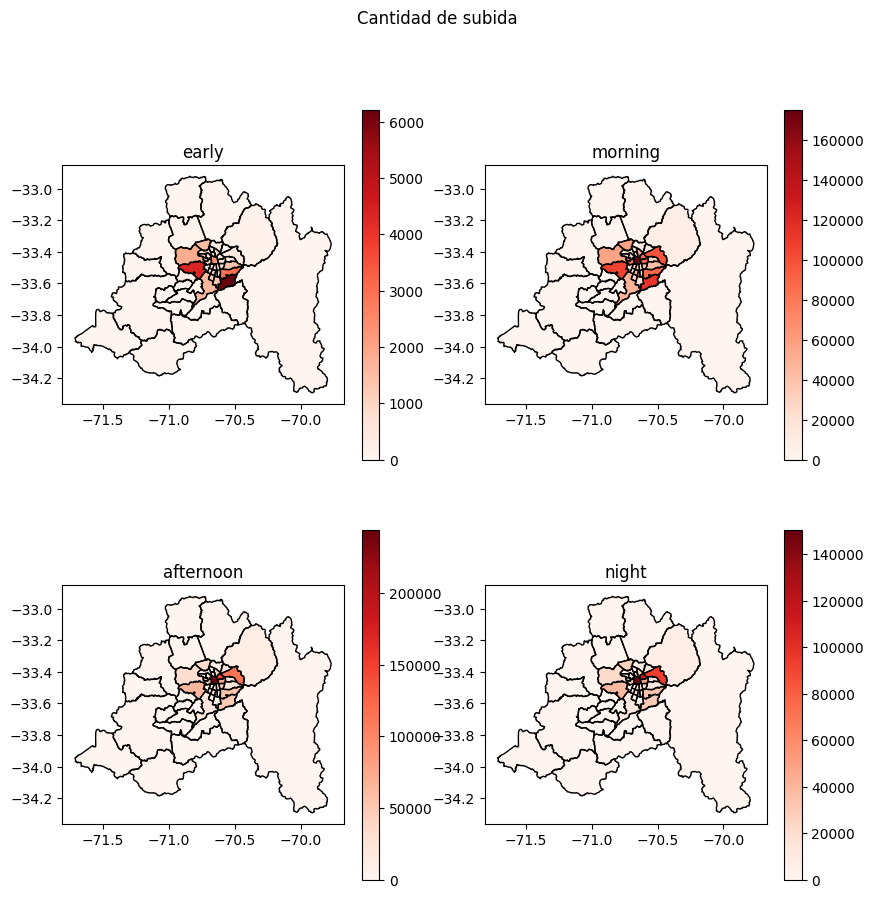

In [24]:
fig = plt.figure(figsize=(10,10))
fig.suptitle("Cantidad de subida")

for i, time in enumerate(["early", "morning", "afternoon", "night"], 1):
    ax = fig.add_subplot(220+i)
    shp_con_dato_subida.boundary.plot(ax=ax, color="black", linewidth=1)
    shp_con_dato_subida.plot(ax=ax, column=time, cmap='Reds', legend=True)
    ax.set_title(time)

## Veamos en que comunas se bajan más:

In [25]:
shp_con_dato_bajada = pd.merge(comunas_santiago, pv_bajada, how="outer", left_on="Comuna", right_index=True)
shp_con_dato_bajada.fillna(0.0, inplace=True)

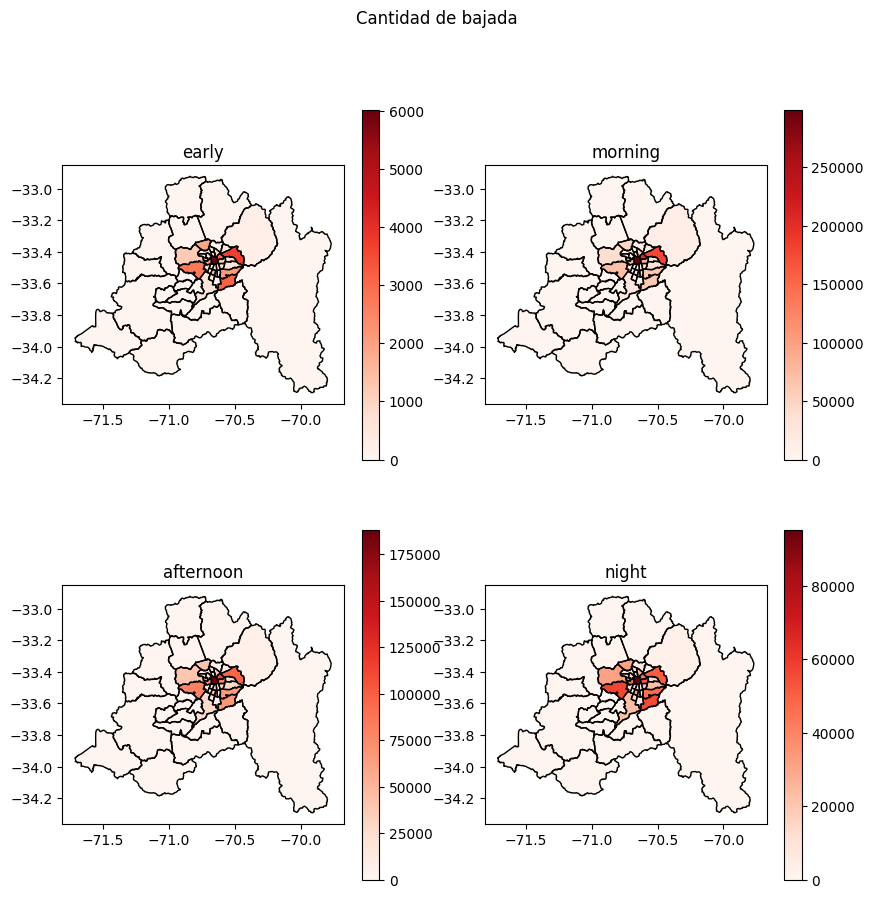

In [26]:
fig = plt.figure(figsize=(10,10))
fig.suptitle("Cantidad de bajada")

for i, time in enumerate(["early", "morning", "afternoon", "night"], 1):
    ax = fig.add_subplot(220+i)
    shp_con_dato_bajada.boundary.plot(ax=ax, color="black", linewidth=1)
    shp_con_dato_bajada.plot(ax=ax, column=time, cmap='Reds', legend=True)
    ax.set_title(time)

## Ahora veamos cuanto tiempo viaja la mayoria de pasajeros:

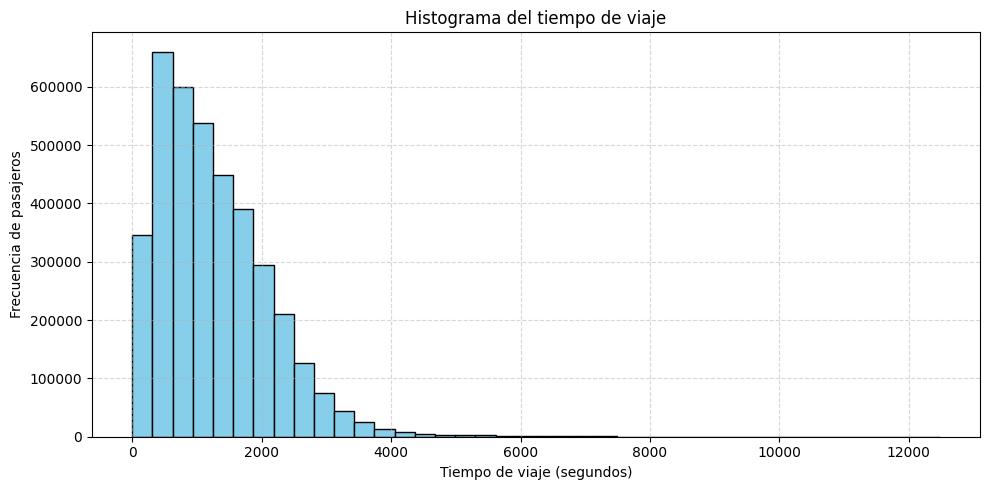

In [27]:


plt.figure(figsize=(10,5))
plt.hist(df_has_bajada['tiempo_etapa'].dropna(), bins=40, color='skyblue', edgecolor='black')
plt.title('Histograma del tiempo de viaje')
plt.xlabel('Tiempo de viaje (segundos)')
plt.ylabel('Frecuencia de pasajeros')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### _Al revisar el grafico podemos ver que la mayoria de datos se encuentran bajo los 1500 segundos! Es decir, los 25 minutos aproximadamente. Podemos ver que en esos viajes existe mayor cantidad de pasajeros_

## Tambien podemos comparar estos mismos tiempos y frecuencia entre cada transporte:

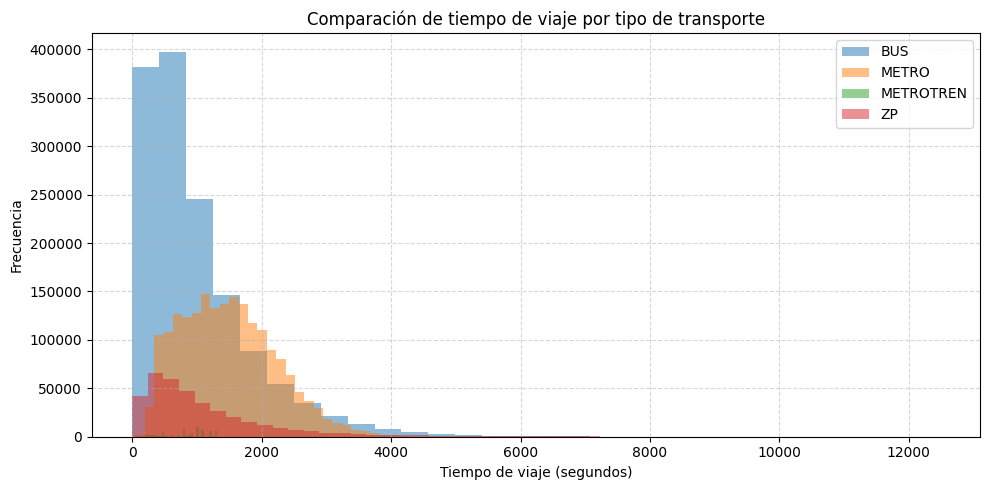

In [28]:
plt.figure(figsize=(10,5))
for tipo in df_has_bajada['tipo_transporte'].dropna().unique():
    subset = df_has_bajada[df_has_bajada['tipo_transporte'] == tipo]['tiempo_etapa'].dropna()
    plt.hist(subset, bins=30, alpha=0.5, label=tipo)

plt.title('Comparación de tiempo de viaje por tipo de transporte')
plt.xlabel('Tiempo de viaje (segundos)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



### _Podemos ver que el metro se utliza para transportes de mayor duracion. A la misma vez la mayoria de viajes en micro tienden a durar menos de 15 minutos (1000 segundos)_


## Tambien queremos ver mejor los horarios en que hay mas personas:

C:\Users\czz\AppData\Local\Temp\ipykernel_12872\1238033252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_has_bajada['hora'] = df_has_bajada['tiempo_subida'].dt.hour


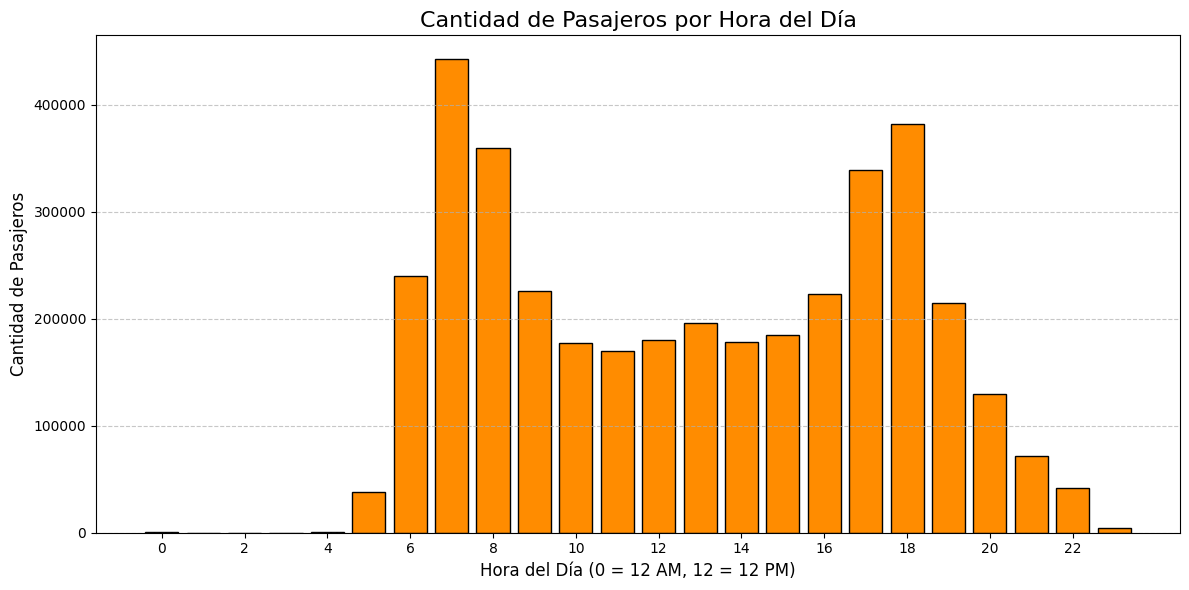

In [29]:
df_has_bajada['hora'] = df_has_bajada['tiempo_subida'].dt.hour

pasajeros_por_hora = df_has_bajada.groupby('hora').size().reset_index(name='cantidad_pasajeros')

# CODIGO SUGERIDO POR IA, PROMPT: "Como puedo asegurar que todas las 24 horas estén presentes"
# Esto garantiza que el gráfico no tenga saltos si no hubo viajes a una hora específica.
# Crea un índice de 0 a 23 y rellena las horas sin datos con 0.
pasajeros_por_hora = pasajeros_por_hora.set_index('hora').reindex(range(24), fill_value=0).reset_index()
# FIN CODIO IA

plt.figure(figsize=(12, 6))
plt.bar(
    pasajeros_por_hora['hora'], 
    pasajeros_por_hora['cantidad_pasajeros'], 
    color='darkorange',
    edgecolor='black'
)

plt.title('Cantidad de Pasajeros por Hora del Día', fontsize=16)
plt.xlabel('Hora del Día (0 = 12 AM, 12 = 12 PM)', fontsize=12)
plt.ylabel('Cantidad de Pasajeros', fontsize=12)

plt.xticks(range(0, 24, 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### _Evidentemente podemos ver en las horas peak (6am-8am y 5pm-6pm) un aumento considerable de la candidad de pasajeros_

## Incluso podemos revisar en que horarios toman mas tiempo los viajes:

C:\Users\czz\AppData\Local\Temp\ipykernel_12872\60329942.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_has_bajada['hora'] = df_has_bajada['hora'].astype('category')


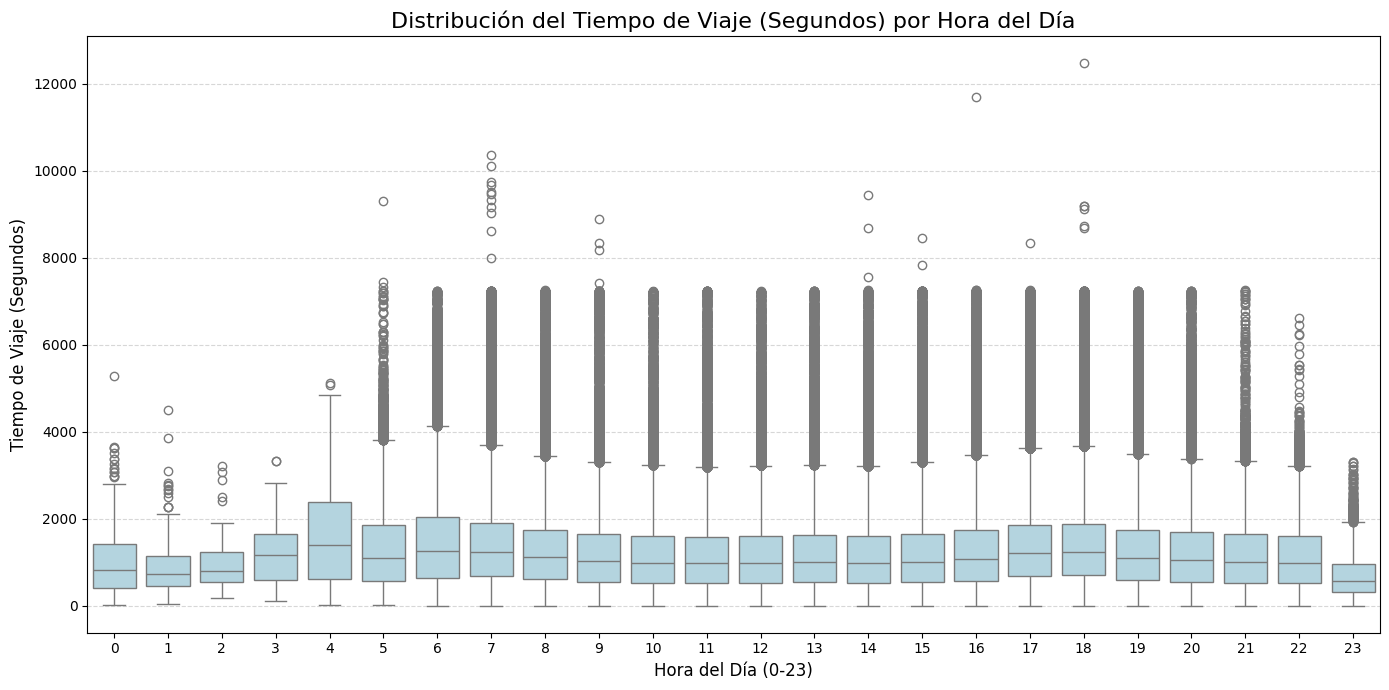

In [30]:
df_has_bajada['hora'] = df_has_bajada['hora'].astype('category')
plt.figure(figsize=(14, 7))

sns.boxplot(x='hora', y='tiempo_etapa', data=df_has_bajada, color='lightblue')

plt.title('Distribución del Tiempo de Viaje (Segundos) por Hora del Día', fontsize=16)
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Tiempo de Viaje (Segundos)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### _Al prestar atencio a este grafico podemos ver que, en las mismas horas peak, existe mayor cantidad de "outliers". En otras palabras, los valores se salen aun mas de rango (toman mas tiempo)_

## Ademas, podemos verificar de donde vienen la mayoria de datos de transporte:

C:\Users\czz\AppData\Local\Temp\ipykernel_12872\2113336938.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pasajeros_por_transporte = df_has_bajada.groupby('tipo_transporte').size().reset_index(name='cantidad_pasajeros')


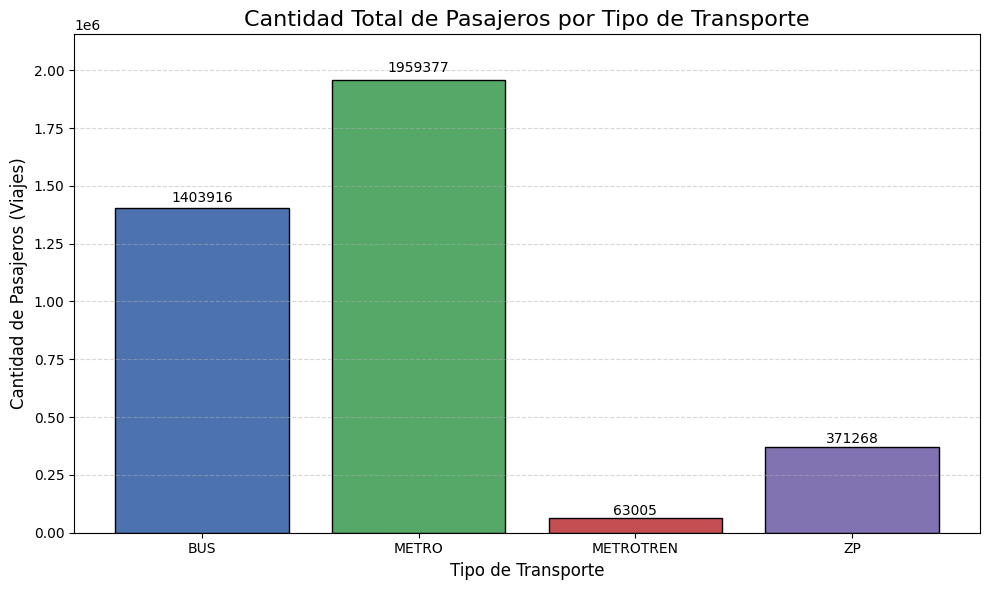

In [31]:
pasajeros_por_transporte = df_has_bajada.groupby('tipo_transporte').size().reset_index(name='cantidad_pasajeros')

plt.figure(figsize=(10, 6))

barras = plt.bar(
    pasajeros_por_transporte['tipo_transporte'], 
    pasajeros_por_transporte['cantidad_pasajeros'], 
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],  # Codigo de colores sugerido por IA, prompt: "Que colores puedo usar en grafico python? Como los anoto?"
    edgecolor='black'
)
for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01), 
             int(yval), ha='center', va='bottom', fontsize=10)

plt.title('Cantidad Total de Pasajeros por Tipo de Transporte', fontsize=16)
plt.xlabel('Tipo de Transporte', fontsize=12)
plt.ylabel('Cantidad de Pasajeros (Viajes)', fontsize=12)

# Quitar el límite superior del eje Y y hacer que el eje Y comience en 0 
plt.ylim(bottom=0, top=pasajeros_por_transporte['cantidad_pasajeros'].max() * 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### _Claramente podemos ver que la mayoria de nuestros datos provienen de transportes como metro o bus_